# 00 — Preparazione dati FSDD

In questo notebook viene preparato il Free Spoken Digit Dataset (FSDD) utilizzato negli esperimenti.
I segnali audio vengono uniformati a una durata di 1 secondo e a una frequenza di campionamento di 8 kHz. Vengono inoltre analizzate le rappresentazioni nel dominio del tempo e della frequenza tramite waveform, STFT e Mel-spettrogramma.
Infine, viene definita la suddivisione train/test adottata in tutti gli esperimenti successivi.


## 1. Librerie e configurazione


In [7]:
from pathlib import Path
import urllib.request
import zipfile

import numpy as np
import torch
import matplotlib.pyplot as plt
import torchaudio
from IPython.display import Audio, display

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAMPLE_RATE = 8000
N_SAMPLES = 8000
N_FFT = 256
HOP_LENGTH = 64
N_MELS = 64

print("device:", device)
print("torch:", torch.__version__)
print("torchaudio:", torchaudio.__version__)


device: cpu
torch: 2.13.0+cpu
torchaudio: 2.11.0+cpu


## 2. Download riproducibile di FSDD v1.0.10


In [8]:
DATA_DIR = Path("audio_data")
DATA_DIR.mkdir(exist_ok=True)

zip_path = DATA_DIR / "fsdd_v1.0.10.zip"
repo_dir = DATA_DIR / "free-spoken-digit-dataset-1.0.10"

if not repo_dir.exists():
    url = "https://github.com/Jakobovski/free-spoken-digit-dataset/archive/refs/tags/v1.0.10.zip"
    print("Download del dataset...")
    urllib.request.urlretrieve(url, zip_path)

    print("Estrazione...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)

recordings_dir = repo_dir / "recordings"
wav_files = sorted(recordings_dir.glob("*.wav"))

print("Numero file audio:", len(wav_files))
print("Esempio:", wav_files[0].name)


Numero file audio: 3000
Esempio: 0_george_0.wav


## 3. Metadati dei file

I file hanno formato:

`cifra_speaker_indice.wav`

Esempio: `7_jackson_32.wav`


In [9]:
def parse_name(path):
    digit, speaker, index = path.stem.split("_")
    return int(digit), speaker, int(index)

digit, speaker, index = parse_name(wav_files[0])

print("digit:", digit)
print("speaker:", speaker)
print("index:", index)


digit: 0
speaker: george
index: 0


## 4. Preprocessing dei segnali audio

In [10]:
import wave as waveio

def load_fixed_audio(path):
    with waveio.open(str(path), "rb") as f:
        sr = f.getframerate()
        channels = f.getnchannels()
        frames = f.readframes(f.getnframes())

    audio = np.frombuffer(
        frames,
        dtype=np.int16
    ).astype(np.float32) / 32768.0

    if channels > 1:
        audio = audio.reshape(-1, channels).mean(axis=1)

    waveform = torch.tensor(
        audio,
        dtype=torch.float32
    ).unsqueeze(0)

    if sr != SAMPLE_RATE:
        waveform = torchaudio.functional.resample(
            waveform,
            sr,
            SAMPLE_RATE
        )

    if waveform.shape[1] < N_SAMPLES:
        pad = N_SAMPLES - waveform.shape[1]
        waveform = torch.nn.functional.pad(
            waveform,
            (0, pad)
        )
    else:
        waveform = waveform[:, :N_SAMPLES]

    return waveform

example_path = wav_files[0]
x = load_fixed_audio(example_path)

print("File:", example_path.name)
print("Shape:", tuple(x.shape))
print("Durata:", x.shape[1] / SAMPLE_RATE, "secondi")

display(Audio(x.squeeze().numpy(), rate=SAMPLE_RATE))


File: 0_george_0.wav
Shape: (1, 8000)
Durata: 1.0 secondi


## 5. Waveform


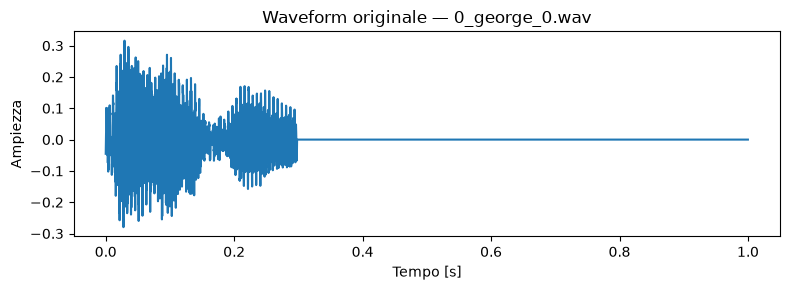

In [11]:
time = np.arange(N_SAMPLES) / SAMPLE_RATE

plt.figure(figsize=(8, 3))
plt.plot(time, x.squeeze().numpy())
plt.xlabel("Tempo [s]")
plt.ylabel("Ampiezza")
plt.title(f"Waveform originale — {example_path.name}")
plt.tight_layout()
plt.show()


## 6. Rappresentazione tempo-frequenza mediante STFT


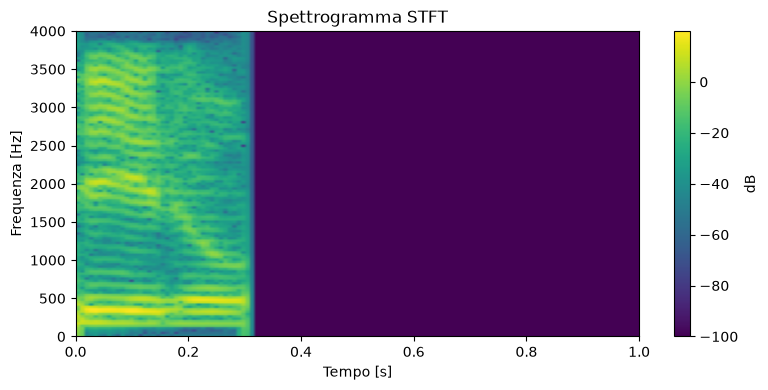

In [12]:
spectrogram = torchaudio.transforms.Spectrogram(
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    power=2.0
)

to_db = torchaudio.transforms.AmplitudeToDB(stype="power")

spec = spectrogram(x)
spec_db = to_db(spec)

plt.figure(figsize=(8, 4))
plt.imshow(
    spec_db.squeeze().numpy(),
    origin="lower",
    aspect="auto",
    extent=[0, 1, 0, SAMPLE_RATE / 2]
)
plt.xlabel("Tempo [s]")
plt.ylabel("Frequenza [Hz]")
plt.title("Spettrogramma STFT")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()


## 7. Rappresentazione Mel-spettrale


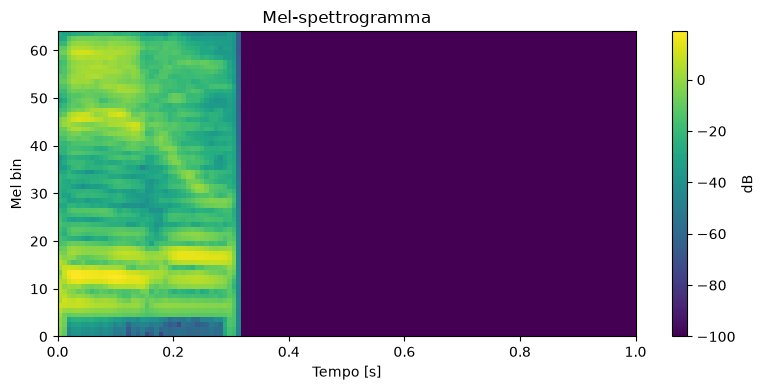

In [13]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    power=2.0
)

mel = mel_transform(x)
mel_db = to_db(mel)

plt.figure(figsize=(8, 4))
plt.imshow(
    mel_db.squeeze().numpy(),
    origin="lower",
    aspect="auto",
    extent=[0, 1, 0, N_MELS]
)
plt.xlabel("Tempo [s]")
plt.ylabel("Mel bin")
plt.title("Mel-spettrogramma")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()


## 8. Suddivisione del dataset in training e test



In [14]:
train_files = []
test_files = []

for path in wav_files:
    _, _, idx = parse_name(path)

    if idx <= 4:
        test_files.append(path)
    else:
        train_files.append(path)

print("Train:", len(train_files))
print("Test:", len(test_files))
print("Totale:", len(train_files) + len(test_files))


Train: 2700
Test: 300
Totale: 3000


## 9. Distorsione controllata: rumore gaussiano

Questa funzione ci servirà più avanti per creare un **denoising VAE**:

- input della rete: audio degradato;
- target: audio originale.

Per ora la usiamo solo per vedere cosa succede al segnale.


In [15]:
def add_noise(x, noise_std=0.05):
    noise = noise_std * torch.randn_like(x)
    return torch.clamp(x + noise, -1.0, 1.0)

x_noisy = add_noise(x, noise_std=0.05)

print("Originale:")
display(Audio(x.squeeze().numpy(), rate=SAMPLE_RATE))

print("Distorto:")
display(Audio(x_noisy.squeeze().numpy(), rate=SAMPLE_RATE))


Originale:


Distorto:


## 10. Confronto visivo originale vs distorto


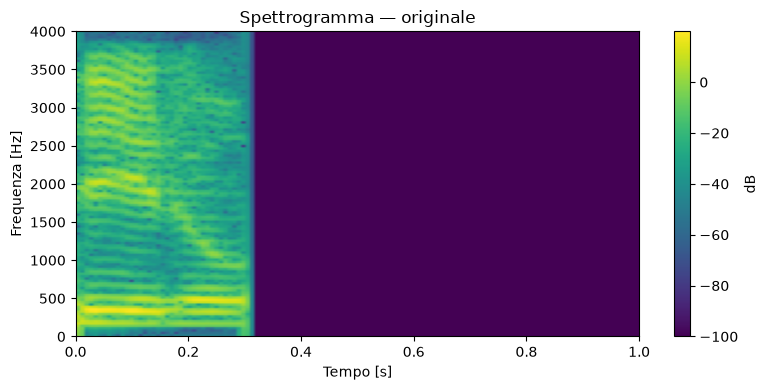

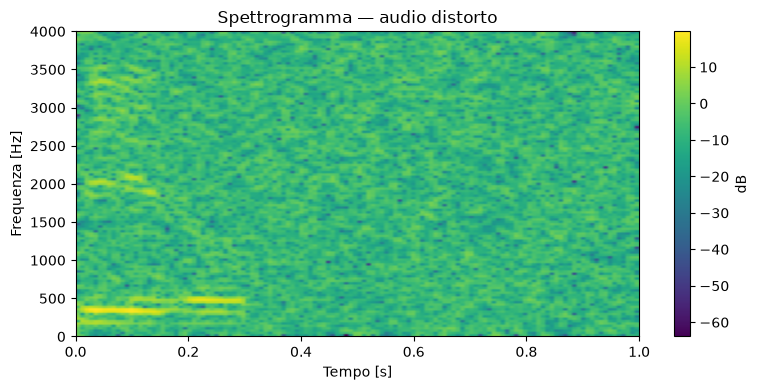

In [16]:
spec_original = to_db(spectrogram(x))
spec_noisy = to_db(spectrogram(x_noisy))

plt.figure(figsize=(8, 4))
plt.imshow(
    spec_original.squeeze().numpy(),
    origin="lower",
    aspect="auto",
    extent=[0, 1, 0, SAMPLE_RATE / 2]
)
plt.xlabel("Tempo [s]")
plt.ylabel("Frequenza [Hz]")
plt.title("Spettrogramma — originale")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.imshow(
    spec_noisy.squeeze().numpy(),
    origin="lower",
    aspect="auto",
    extent=[0, 1, 0, SAMPLE_RATE / 2]
)
plt.xlabel("Tempo [s]")
plt.ylabel("Frequenza [Hz]")
plt.title("Spettrogramma — audio distorto")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()


# Conclusioni

Il dataset è stato correttamente preparato e suddiviso nelle partizioni di training e test. Le rappresentazioni spettrali ottenute saranno utilizzate come input per l’autoencoder e, successivamente, per il VAE.
